### Market Dynamics and btc power law analyses

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import QuantLib as ql

In [2]:
btc_data = yf.Ticker("BTC-USD").history(start='2008-01-01',end='2026-01-29', interval="1d")
#btc_data.reset_index(inplace=True)
#btc_data['Date'] = pd.to_datetime(btc_data['Date'])
#btc_data.set_index('Date', inplace=True)
btc_data#['Returns'] = btc_data['Close'].pct_change()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...
2026-01-24 00:00:00+00:00,89506.148438,89811.609375,89044.289062,89110.734375,14558687712,0.0,0.0
2026-01-25 00:00:00+00:00,89104.765625,89193.148438,86003.710938,86572.218750,36124986722,0.0,0.0
2026-01-26 00:00:00+00:00,86566.523438,88743.070312,86429.289062,88267.140625,45329286974,0.0,0.0


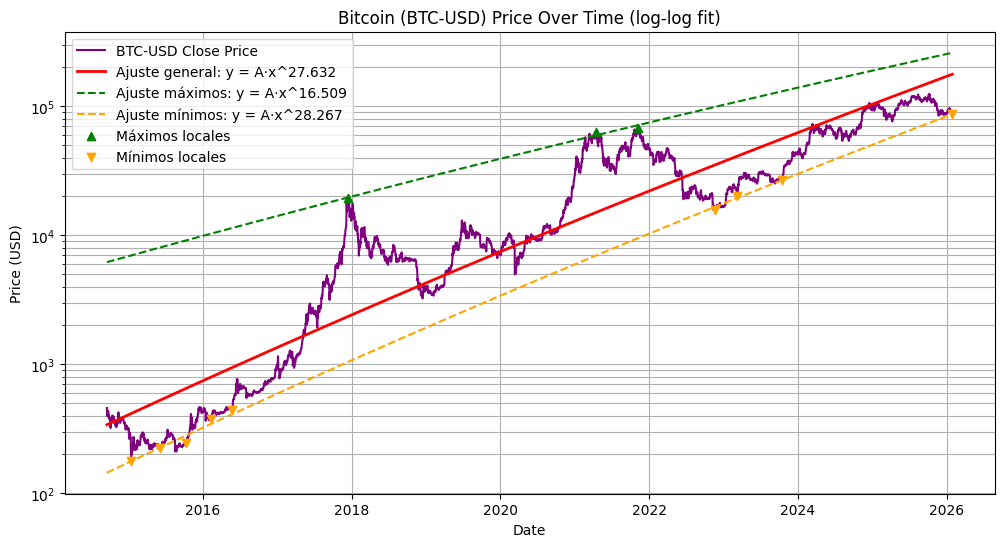

In [3]:
from matplotlib import dates as mdates
from scipy.signal import find_peaks # Importar la función para encontrar picos
import numpy as np

# Convert dates to numeric values (days) for log-log fitting
x_num = mdates.date2num(btc_data.index.to_pydatetime())
y = btc_data['Close'].values

# Keep only positive values (necesario para log)
mask = (x_num > 0) & (y > 0)
x_num = x_num[mask]
y = y[mask]

# Ajuste lineal en escala log-log
logx = np.log(x_num)
logy = np.log(y)
slope, intercept = np.polyfit(logx, logy, 1)  # logy = slope*logx + intercept

# Curva ajustada en el espacio original: y = exp(intercept) * x^slope
y_fit = np.exp(intercept) * (x_num ** slope)

# --- Encontrar y ajustar máximos y mínimos ---
# Encontrar picos (máximos locales). `distance` ayuda a evitar picos pequeños y cercanos.
peaks, _ = find_peaks(y, distance=150, prominence=y_fit*1.5)
# Encontrar valles (mínimos locales) invirtiendo la serie
#troughs, _ = find_peaks(-y ,distance=150, prominence=-y_fit*.6)

# Encontrar valles (mínimos locales) usando datos sin tendencia para poder usar 'height'.
# 1. Quitar la tendencia a la serie para que los valles sean comparables.
y_detrended = y - y_fit
# 2. Invertir la serie. Los valles ahora son picos altos.
y_inv_detrended = -y_detrended
# 3. Encontrar picos usando 'height' para filtrar solo los valles más profundos.
#    Un buen umbral inicial es la desviación estándar de la serie sin tendencia.
height_threshold = y_fit*.5#np.std(y_inv_detrended) * 0.3 # Puedes ajustar el multiplicador 0.5
troughs, _ = find_peaks(y_inv_detrended, distance=100, height=height_threshold)

# Ajuste para máximos
x_peaks = x_num[peaks]
y_peaks = y[peaks]
logx_peaks = np.log(x_peaks)
logy_peaks = np.log(y_peaks)
slope_peaks, intercept_peaks = np.polyfit(logx_peaks, logy_peaks, 1)
y_fit_peaks = np.exp(intercept_peaks) * (x_num ** slope_peaks)

# Ajuste para mínimos
x_troughs = x_num[troughs]
y_troughs = y[troughs]
logx_troughs = np.log(x_troughs)
logy_troughs = np.log(y_troughs)
slope_troughs, intercept_troughs = np.polyfit(logx_troughs, logy_troughs, 1)
y_fit_troughs = np.exp(intercept_troughs) * (x_num ** slope_troughs)

# --- Ploteo ---
plt.figure(figsize=(12, 6))
plt.plot(btc_data.index, btc_data['Close'], label='BTC-USD Close Price', color='purple')
plt.plot(mdates.num2date(x_num), y_fit, label=f'Ajuste general: y = A·x^{slope:.3f}', color='red', linewidth=2)

# Graficar nuevos ajustes
plt.plot(mdates.num2date(x_num), y_fit_peaks, label=f'Ajuste máximos: y = A·x^{slope_peaks:.3f}', color='green', linestyle='--')
plt.plot(mdates.num2date(x_num), y_fit_troughs, label=f'Ajuste mínimos: y = A·x^{slope_troughs:.3f}', color='orange', linestyle='--')

# Opcional: mostrar los puntos de máximos y mínimos encontrados
plt.scatter(mdates.num2date(x_peaks), y_peaks, color='green', marker='^', zorder=5, label='Máximos locales')
plt.scatter(mdates.num2date(x_troughs), y_troughs, color='orange', marker='v', zorder=5, label='Mínimos locales')

plt.title('Bitcoin (BTC-USD) Price Over Time (log-log fit)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
#plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

general_vs_troughs: intersection x_num fuera de rango (6.28e+04), se omite
general_vs_peaks: 2028-01-17  price=459927.07
general_vs_troughs: sin fecha válida (o fuera de rango)
peaks_vs_troughs: 2031-07-21  price=1212299.47


C:\Users\marti\AppData\Local\Temp\ipykernel_21304\2770687607.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


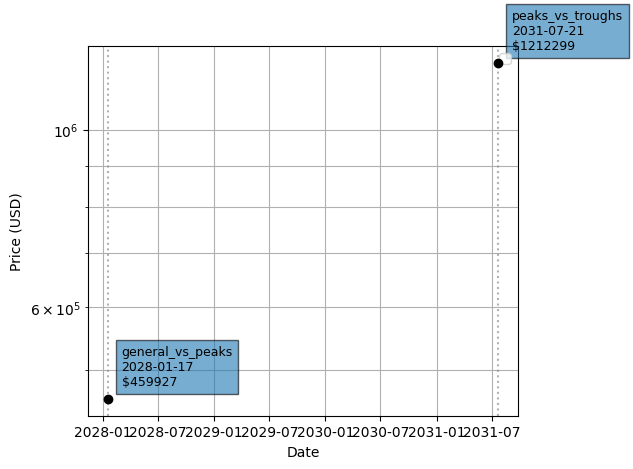

In [5]:
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

def pow_intersection(s1, c1, s2, c2, tol=1e-12):
    # s are slopes, c are intercepts (log A). retorna x_num (matplotlib date num) o None
    if np.isclose(s1, s2, atol=tol):
        return None
    logx = (c2 - c1) / (s1 - s2)
    x = np.exp(logx)
    return x

# --- calcular intersecciones entre los tres fits que ya tienes ---
pairs = {
    'general_vs_peaks': (slope, intercept, slope_peaks, intercept_peaks),
    'general_vs_troughs': (slope, intercept, slope_troughs, intercept_troughs),
    'peaks_vs_troughs': (slope_peaks, intercept_peaks, slope_troughs, intercept_troughs),
}

# validar y normalizar intersecciones antes de convertir a pandas datetime
valid_intersections = {}
proj_margin = 365 * 10  # límite razonable (10 años extra) para aceptar intersecciones
x_min = x_num.min()
x_max = x_num.max()

for name, (s1, c1, s2, c2) in pairs.items():
    x_int = pow_intersection(s1, c1, s2, c2)
    if x_int is None or not np.isfinite(x_int):
        valid_intersections[name] = None
        continue

    # opcional: solo aceptar intersecciones dentro de un rango razonable
    if not (x_min - proj_margin <= x_int <= x_max + proj_margin):
        print(f"{name}: intersection x_num fuera de rango ({x_int:.2e}), se omite")
        valid_intersections[name] = (x_int, None, np.exp(c1) * (x_int ** s1))
        continue

    # intentar convertir a datetime de forma segura
    try:
        date_int = mdates.num2date(x_int)         # devuelve datetime.datetime
        # convertir a pandas.Timestamp solo si cabe en el rango
        pd_date = pd.to_datetime(date_int)
    except Exception as e:
        print(f"{name}: conversión fecha falló ({e}), x_num={x_int:.2e}")
        valid_intersections[name] = (x_int, None, np.exp(c1) * (x_int ** s1))
        continue

    y_int = np.exp(c1) * (x_int ** s1)
    valid_intersections[name] = (x_int, pd_date, y_int)

# imprimir de forma segura
for k, v in valid_intersections.items():
    if v is None or v[1] is None:
        print(f"{k}: sin fecha válida (o fuera de rango)")
    else:
        _, date_int, y_int = v
        print(f"{k}: {date_int.strftime('%Y-%m-%d')}  price={y_int:.2f}")

# en la parte de graficar, usa valid_intersections y omite las que no tienen fecha
for name, val in valid_intersections.items():
    if val is None:
        continue
    x_int, date_int, y_int = val
    if date_int is None:
        continue
    plt.axvline(date_int, color='gray', alpha=0.6, ls=':')
    plt.scatter([date_int], [y_int], color='black', zorder=10)
    plt.annotate(f"{name}\n{date_int.strftime('%Y-%m-%d')}\n${y_int:.0f}",
                 (date_int, y_int),
                 textcoords="offset points", xytext=(10,10), fontsize=9, bbox=dict(alpha=0.6))

plt.yscale('log')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, which='both', ls='-')
plt.tight_layout()
plt.show()

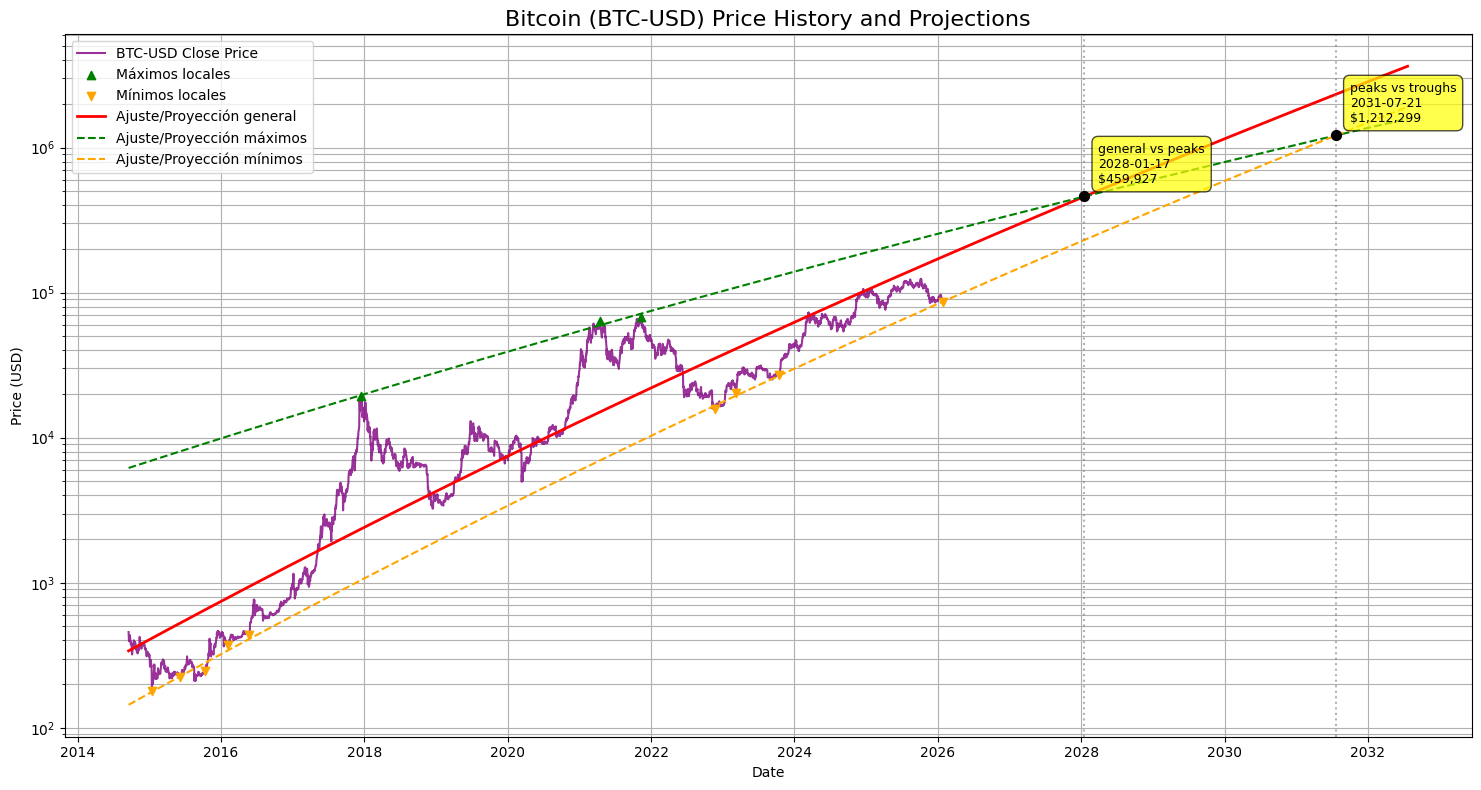

In [6]:

# --- Graficar todo en un solo lugar: Histórico + Proyecciones ---

# 1. Definir el rango de fechas para la proyección
# Proyectamos hasta un año después de la última intersección encontrada
last_intersection_date = max(d[1] for d in valid_intersections.values() if d and d[1])
x_proj_end_num = mdates.date2num(last_intersection_date) + 365
x_proj = np.linspace(x_num[0], x_proj_end_num, 4089)
dates_proj = mdates.num2date(x_proj)

# 2. Calcular las curvas de ajuste para el rango proyectado
y_proj_general = np.exp(intercept) * (x_proj ** slope)
y_proj_peaks   = np.exp(intercept_peaks) * (x_proj ** slope_peaks)
y_proj_troughs = np.exp(intercept_troughs) * (x_proj ** slope_troughs)

# 3. Crear el gráfico
plt.figure(figsize=(15, 8))

# --- Plotear los datos históricos y los ajustes originales ---
# Precio histórico
plt.plot(btc_data.index, btc_data['Close'], label='BTC-USD Close Price', color='purple', alpha=0.8)
# Puntos de máximos y mínimos encontrados
plt.scatter(mdates.num2date(x_peaks), y_peaks, color='green', marker='^', zorder=5, label='Máximos locales')
plt.scatter(mdates.num2date(x_troughs), y_troughs, color='orange', marker='v', zorder=5, label='Mínimos locales')

# --- Plotear las proyecciones extendidas ---
plt.plot(dates_proj, y_proj_general, label=f'Ajuste/Proyección general', color='red', linewidth=2)
plt.plot(dates_proj, y_proj_peaks, label=f'Ajuste/Proyección máximos', color='green', linestyle='--')
plt.plot(dates_proj, y_proj_troughs, label=f'Ajuste/Proyección mínimos', color='orange', linestyle='--')
''''''
# --- Plotear y anotar los puntos de intersección ---
for name, val in valid_intersections.items():
    if val is None or val[1] is None:
        continue
    x_int, date_int, y_int = val
    # Dibuja un punto grande y una línea vertical para destacar la intersección
    plt.axvline(date_int, color='gray', alpha=0.6, ls=':')
    plt.scatter([date_int], [y_int], color='black', s=50, zorder=10)
    plt.annotate(f"{name.replace('_', ' ')}\n{date_int.strftime('%Y-%m-%d')}\n${y_int:,.0f}",
                 (date_int, y_int),
                 textcoords="offset points", 
                 xytext=(10, 10), 
                 fontsize=9, 
                 bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.7))


# --- Configuración final del gráfico ---
plt.yscale('log')
plt.title('Bitcoin (BTC-USD) Price History and Projections', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# Ajustar los límites para que se vea bien
#plt.xlim([btc_data.index[0], dates_proj[-1]])
#plt.ylim([btc_data['Close'].min() * 0.5, y_int * 2]) # Ajusta el límite superior basado en la última intersección
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()


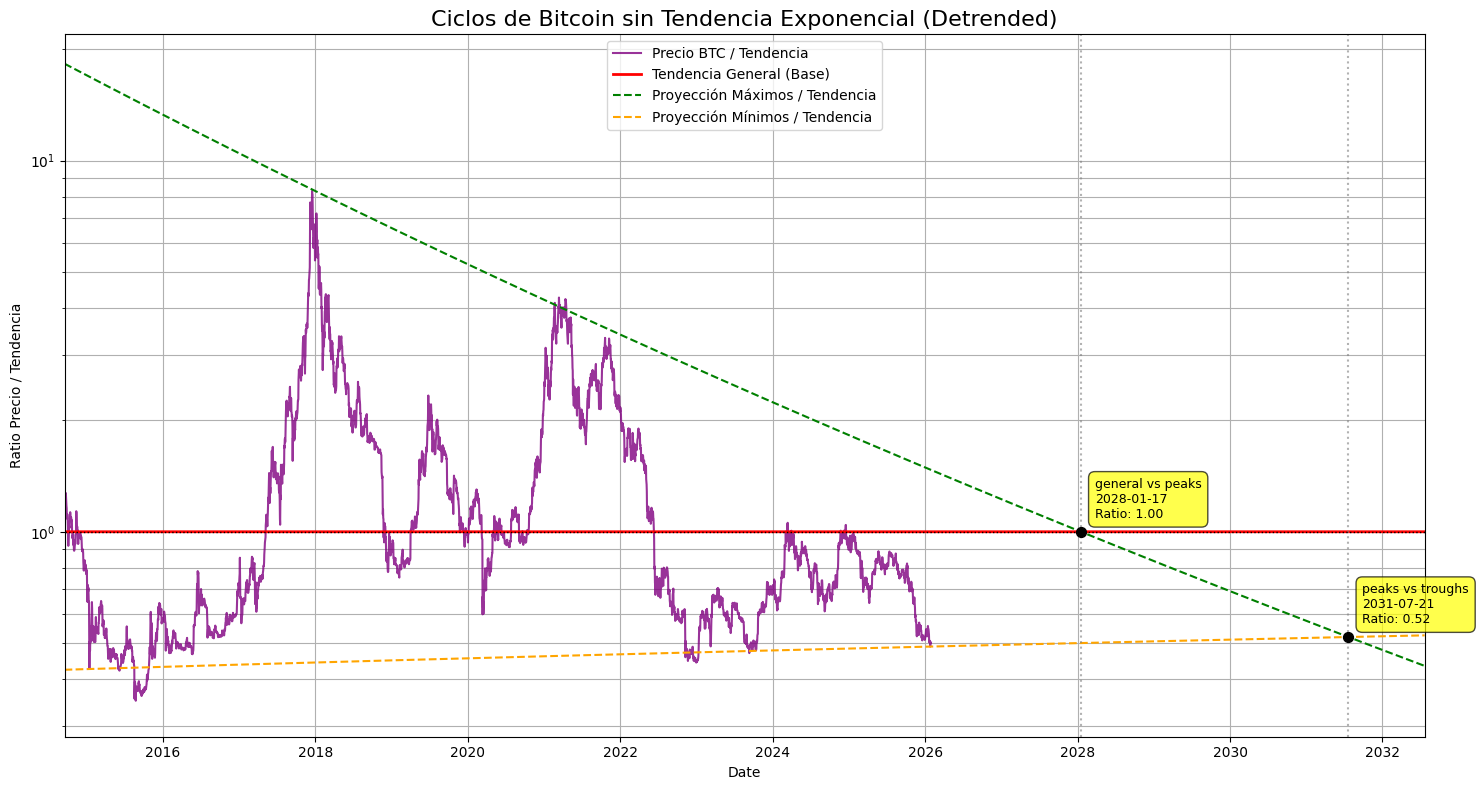

In [7]:
# --- Graficar proyecciones sin tendencia (detrended) ---

# 1. Usar las proyecciones calculadas en la celda anterior
# La tendencia que vamos a remover es la 'proyección general'
trend_to_remove_proj = y_proj_general

# 2. Calcular los valores históricos y de las proyecciones sin la tendencia principal
#    Se divide cada serie por el valor de la tendencia general en ese mismo punto.
y_hist_detrended = y / y_fit # y_fit es la tendencia sobre el período histórico
y_proj_peaks_detrended = y_proj_peaks / trend_to_remove_proj
y_proj_troughs_detrended = y_proj_troughs / trend_to_remove_proj

# 3. Crear el gráfico sin tendencia
plt.figure(figsize=(15, 8))

# --- Plotear los datos y curvas sin tendencia ---
# Datos históricos sin tendencia
plt.plot(btc_data.index, y_hist_detrended, label='Precio BTC / Tendencia', color='purple', alpha=0.8)

# La tendencia general ahora es una línea horizontal en y=1
plt.plot(dates_proj, np.ones_like(dates_proj), label='Tendencia General (Base)', color='red', linewidth=2)

# Proyecciones de picos y valles sin tendencia
plt.plot(dates_proj, y_proj_peaks_detrended, label='Proyección Máximos / Tendencia', color='green', linestyle='--')
plt.plot(dates_proj, y_proj_troughs_detrended, label='Proyección Mínimos / Tendencia', color='orange', linestyle='--')

# --- Plotear y anotar los puntos de intersección sin tendencia ---
for name, val in valid_intersections.items():
    if val is None or val[1] is None:
        continue
    x_int, date_int, y_int = val
    
    # Calcular el valor de la tendencia general en el punto de intersección
    trend_at_intersection = np.exp(intercept) * (x_int ** slope)
    
    # Calcular el valor 'y' sin tendencia para la intersección
    y_int_detrended = y_int / trend_at_intersection
    
    # Dibuja el punto y la línea
    plt.axvline(date_int, color='gray', alpha=0.6, ls=':')
    plt.scatter([date_int], [y_int_detrended], color='black', s=50, zorder=10)
    plt.annotate(f"{name.replace('_', ' ')}\n{date_int.strftime('%Y-%m-%d')}\nRatio: {y_int_detrended:.2f}",
                 (date_int, y_int_detrended),
                 textcoords="offset points", 
                 xytext=(10, 10), 
                 fontsize=9, 
                 bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.7))

# --- Configuración final del gráfico ---
plt.yscale('log') # La escala logarítmica sigue siendo útil para ver desviaciones porcentuales
plt.title('Ciclos de Bitcoin sin Tendencia Exponencial (Detrended)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Ratio Precio / Tendencia')
plt.axhline(1.0, color='black', linestyle=':', linewidth=1) # Línea de referencia en 1.0

# Ajustar límites para una mejor visualización
plt.xlim([btc_data.index[0], dates_proj[-1]])
all_y_detrended = np.concatenate([y_hist_detrended, y_proj_peaks_detrended, y_proj_troughs_detrended])
plt.ylim([np.nanmin(all_y_detrended) * 0.8, np.nanmax(all_y_detrended) * 1.2])

plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()


In [ ]:
ticker = "RENDER-USD"
#cripto_data = yf.Ticker(ticker).history( start="2025-10-01", end="2025-10-09", interval="15m")

cripto_data = yf.Ticker(ticker).history(period="max", interval="1d")
cripto_data = cripto_data.iloc[ : , :-2]  # Seleccionar solo las primeras 5 columnas
cripto_data#.head(20)

,Open,High,Low,Close,Volume
Date,,,,,
2020-06-11 00:00:00+00:00,0.038856,0.078568,0.038751,0.055727,23544
2020-06-12 00:00:00+00:00,0.055748,0.063758,0.043086,0.053068,12740
2020-06-13 00:00:00+00:00,0.053079,0.054382,0.040944,0.046767,20434
2020-06-14 00:00:00+00:00,0.046766,0.055298,0.044848,0.049426,17208
2020-06-15 00:00:00+00:00,0.049430,0.055058,0.037573,0.051250,21152
...,...,...,...,...,...
2025-10-13 00:00:00+00:00,2.738851,3.079637,2.710876,3.052456,136203898
2025-10-14 00:00:00+00:00,3.052682,3.059629,2.689252,2.854767,106041582
2025-10-15 00:00:00+00:00,2.854767,2.911129,2.645832,2.681351,60507068


In [45]:
logrets = np.log(cripto_data['Close'] / cripto_data['Close'].shift(1))
cripto_data['Velocity'] = logrets
cripto_data['Acceleration'] = cripto_data['Velocity'].diff()
cripto_data = cripto_data.dropna()
cripto_data


,Open,High,Low,Close,Volume,Velocity,Acceleration
Date,,,,,,,
2020-06-13 00:00:00+00:00,0.053079,0.054382,0.040944,0.046767,20434,-0.126396,-0.077506
2020-06-14 00:00:00+00:00,0.046766,0.055298,0.044848,0.049426,17208,0.055299,0.181695
2020-06-15 00:00:00+00:00,0.049430,0.055058,0.037573,0.051250,21152,0.036239,-0.019060
2020-06-16 00:00:00+00:00,0.051246,0.066447,0.036764,0.060849,23300,0.171680,0.135441
2020-06-17 00:00:00+00:00,0.060841,0.097300,0.043286,0.097290,54573,0.469301,0.297621
...,...,...,...,...,...,...,...
2025-10-13 00:00:00+00:00,2.738851,3.079637,2.710876,3.052456,136203898,0.108336,-0.037257
2025-10-14 00:00:00+00:00,3.052682,3.059629,2.689252,2.854767,106041582,-0.066956,-0.175292
2025-10-15 00:00:00+00:00,2.854767,2.911129,2.645832,2.681351,60507068,-0.062670,0.004287


In [ ]:

cripto_data = cripto_data.loc['2025-10-07':,:]
cripto_data = cripto_data.resample('15min').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum',
    'Velocity': 'mean',
    'Acceleration': 'mean'
}).dropna()
cripto_data

"\nplt.subplot(3, 1, 2)\n#plt.plot(cripto_data.index, cripto_data['Velocity'], label='Velocidad (Rendimiento Logarítmico)', color='orange')\nplt.plot(cripto_data.index, cripto_data['Velocity'].rolling(window=6).mean()+.004, label='Rapidez (Media Móvil)', color='green')\nplt.title(f'Velocidad de {ticker}')\nplt.xlabel('Fecha')\nplt.ylabel('Velocidad')\nplt.legend()\nplt.grid() \nplt.tight_layout() \n\nplt.subplot(3, 1, 3)\n#plt.plot(cripto_data.index, cripto_data['Acceleration'], label='Aceleración', color='purple')\nplt.plot(cripto_data.index, cripto_data['Acceleration'].rolling(window=6).mean()+.004, label='Aceleración (Media Móvil 5)', color='green')\nplt.title(f'Aceleración de {ticker}')\nplt.xlabel('Fecha')\nplt.ylabel('Aceleración')\nplt.legend()\nplt.grid()\nplt.tight_layout()"

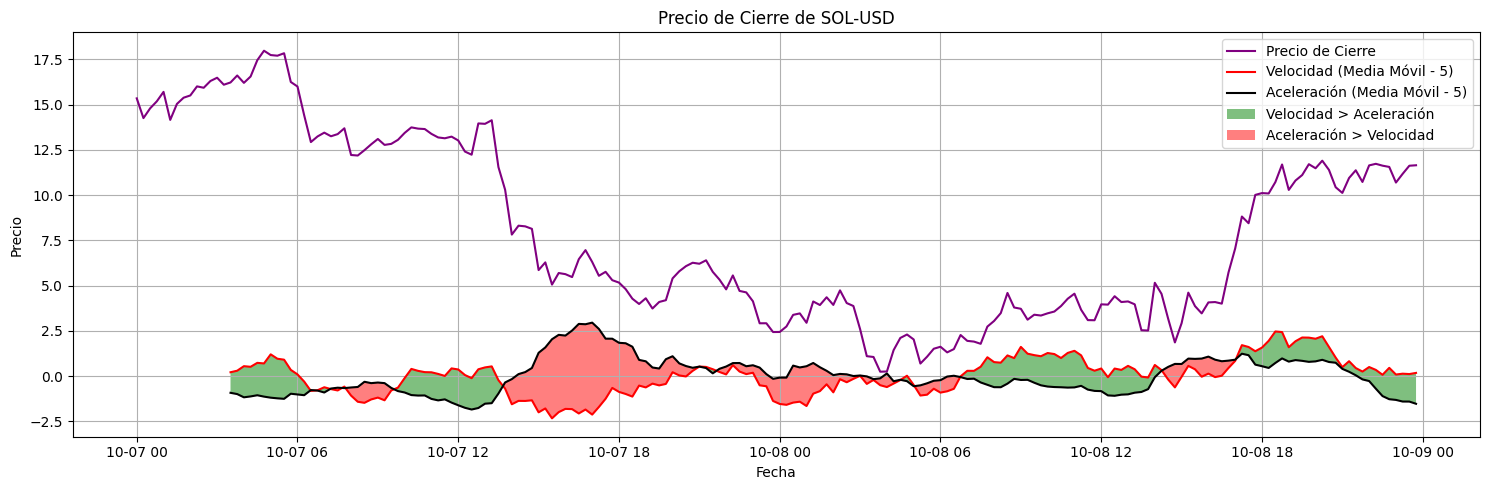

In [5]:
import QuantLib as ql

window = 15
# Calculamos las series normalizadas para mayor claridad
close_norm = ql.standar_norm(cripto_data['Close'])
velocity_norm = ql.standar_norm(cripto_data['Velocity'].rolling(window=window).mean())
acceleration_norm = ql.standar_norm(cripto_data['Acceleration'].rolling(window=window).mean())

plt.figure(figsize=(15, 5))
#plt.subplot(3, 1, 1)
plt.plot(cripto_data.index, ql.standar_norm(cripto_data['Close'])*5+8, label='Precio de Cierre', color='purple')
plt.plot(cripto_data.index, ql.standar_norm(cripto_data['Velocity'].rolling(window=window).mean()), label='Velocidad (Media Móvil - 5)', color='red')
plt.plot(cripto_data.index, ql.standar_norm(cripto_data['Acceleration'].rolling(window=window).mean()), label='Aceleración (Media Móvil - 5)', color='black')

# Coloreamos el área entre velocidad y aceleración
#plt.fill_between(cripto_data.index, velocity_norm, acceleration_norm, color='gray', alpha=0.3, label='Area Velocidad-Aceleración')

# Coloreamos el área entre velocidad y aceleración con colores condicionales
plt.fill_between(cripto_data.index, velocity_norm, acceleration_norm, where=velocity_norm >= acceleration_norm, facecolor='green', alpha=0.5, interpolate=True, label='Velocidad > Aceleración')
plt.fill_between(cripto_data.index, velocity_norm, acceleration_norm, where=velocity_norm < acceleration_norm, facecolor='red', alpha=0.5, interpolate=True, label='Aceleración > Velocidad')



plt.title(f'Precio de Cierre de {ticker}')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid()  
plt.tight_layout()

'''
plt.subplot(3, 1, 2)
#plt.plot(cripto_data.index, cripto_data['Velocity'], label='Velocidad (Rendimiento Logarítmico)', color='orange')
plt.plot(cripto_data.index, cripto_data['Velocity'].rolling(window=6).mean()+.004, label='Rapidez (Media Móvil)', color='green')
plt.title(f'Velocidad de {ticker}')
plt.xlabel('Fecha')
plt.ylabel('Velocidad')
plt.legend()
plt.grid() 
plt.tight_layout() 

plt.subplot(3, 1, 3)
#plt.plot(cripto_data.index, cripto_data['Acceleration'], label='Aceleración', color='purple')
plt.plot(cripto_data.index, cripto_data['Acceleration'].rolling(window=6).mean()+.004, label='Aceleración (Media Móvil 5)', color='green')
plt.title(f'Aceleración de {ticker}')
plt.xlabel('Fecha')
plt.ylabel('Aceleración')
plt.legend()
plt.grid()
plt.tight_layout()'''

#### MArket Energy

In [23]:
import QuantLib as ql
cripto_res=ql.resample_by_trading_minutes(cripto_data, n_minutes=30, on=None, agg=None, label='end')
cripto_res

,Open,High,Low,Close,Volume
2025-10-01 01:00:00,208.912643,209.182358,206.640182,207.534241,27306496
2025-10-01 01:55:00,207.541336,210.203064,207.402145,210.171921,37512192
2025-10-01 02:57:00,210.477966,210.788620,209.508774,209.558884,68336640
2025-10-01 03:45:00,209.374939,209.487061,208.499619,208.502716,56771072
2025-10-01 04:20:00,207.871704,208.436035,206.827087,208.436035,141487104
...,...,...,...,...,...
2025-10-08 22:05:00,228.742004,229.003265,228.015213,228.875473,28658688
2025-10-08 22:38:00,228.856827,229.359070,228.856827,229.240707,56428544
2025-10-08 23:12:00,229.253616,229.265686,228.165146,228.186279,32268800
2025-10-08 23:49:00,228.222183,229.260345,228.126633,229.136963,16008192


In [19]:
cripto_data.resample('15min').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()
cripto_data

,Open,High,Low,Close,Volume
Datetime,,,,,
2025-10-01 00:02:00+00:00,208.912643,208.912643,208.912643,208.912643,0
2025-10-01 00:04:00+00:00,209.104080,209.104080,209.104080,209.104080,12412928
2025-10-01 00:06:00+00:00,209.128235,209.128235,209.128235,209.128235,2008576
2025-10-01 00:08:00+00:00,209.182358,209.182358,209.182358,209.182358,4100608
2025-10-01 00:10:00+00:00,209.074341,209.074341,209.074341,209.074341,592384
...,...,...,...,...,...
2025-10-08 23:53:00+00:00,229.044601,229.044601,229.044601,229.044601,0
2025-10-08 23:54:00+00:00,229.059372,229.059372,229.059372,229.059372,0
2025-10-08 23:55:00+00:00,229.064011,229.064011,229.064011,229.064011,0


In [46]:
prices = cripto_data[['Close']]
prices

,Close
Date,
2020-06-13 00:00:00+00:00,0.046767
2020-06-14 00:00:00+00:00,0.049426
2020-06-15 00:00:00+00:00,0.051250
2020-06-16 00:00:00+00:00,0.060849
2020-06-17 00:00:00+00:00,0.097290
...,...
2025-10-13 00:00:00+00:00,3.052456
2025-10-14 00:00:00+00:00,2.854767
2025-10-15 00:00:00+00:00,2.681351


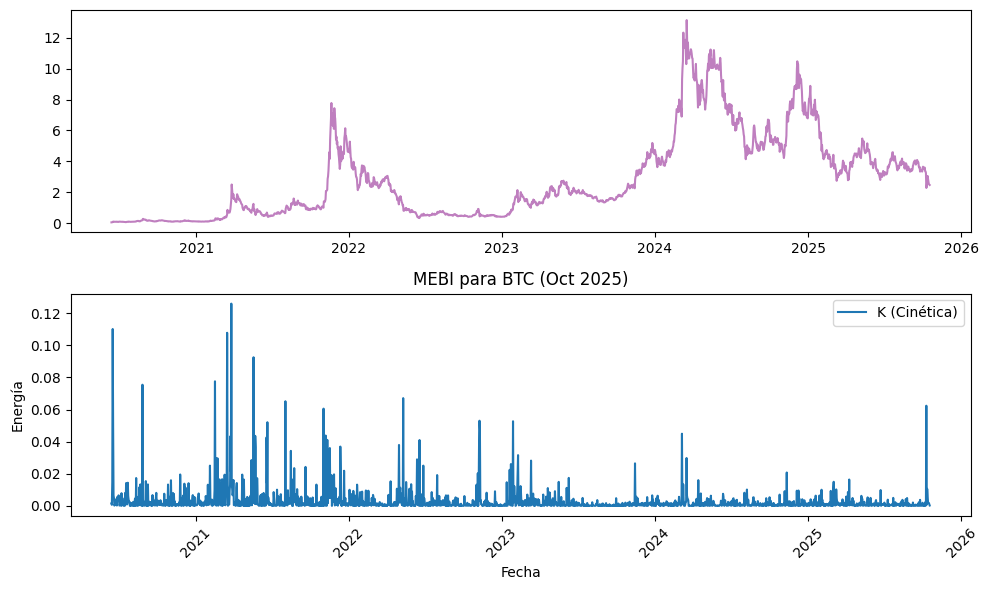

Correlación E con retornos futuros: 0.05


In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Datos ejemplo: Reemplaza con tu array de precios
#prices = np.array([118576.20, 120566.10, 122224.20, 122387.10, 123475.50, 124725.10, 121356.60, 123311.10, 121666.30, 112878.60, 110671.50, 114986.00, 114282.50])
prices = cripto_data['Close'].values
#dates = np.array(['2025-10-01', '2025-10-02', '2025-10-03', '2025-10-04', '2025-10-05', '2025-10-06', '2025-10-07', '2025-10-08', '2025-10-09', '2025-10-10', '2025-10-11', '2025-10-12', '2025-10-13'])
dates = cripto_data.index

m = 1  # Normalizado; usa market cap real para escala

log_prices = np.log(prices)
r = np.diff(log_prices)  # Retornos/Velocidades
a = np.diff(r)  # Aceleraciones

# Infer V acumulada: - sum(a * delta_p), delta_p = r[1:]
delta_p = r[1:]
#V_cum = -m * np.cumsum( a * delta_p)
V_cum = -m *  a * delta_p

# K
K = 0.5 * m * r**2

# E = K[1:] + V_cum
E = K[1:] + V_cum

# Plot
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(dates, prices, label='Precio de Cierre', color='purple', alpha=0.5)

plt.subplot(2, 1, 2)
plt.plot(dates[1:], K, label='K (Cinética)')
#plt.plot(dates[2:], V_cum, label='V (Potencial Inferido)')
#plt.plot(dates[2:], E, label='E Total', color='black', linewidth=2)
plt.xlabel('Fecha')
plt.ylabel('Energía')
plt.title('MEBI para BTC (Oct 2025)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Correlación ejemplo: Con retornos futuros (shift)
corr = np.corrcoef(E[:-1], r[2:])[0,1]  # E con retornos siguientes
print(f'Correlación E con retornos futuros: {corr:.2f}')